## Numerical Solution of the Laplace Equation on Irregular Domains

### Theoretical Framework

In many physical scenarios—such as electrostatics or steady-state heat conduction—the system dynamics are governed by the Laplace Equation for a potential field $\Phi$:
$$\nabla^2 \Phi = \frac{\partial^2 \Phi}{\partial x^2} + \frac{\partial^2 \Phi}{\partial y^2} = 0$$
When dealing with complex geometries where boundary walls do not align perfectly with a uniform grid, standard finite difference approximations fail. To resolve this, we employ a Modified Taylor Stencil incorporating geometric scaling parameters ($\alpha_1, \alpha_2, \beta_1, \beta_2$) to correctly weight the spatial derivatives near irregular nodes.After computing the potential distribution, the associated vector flux fields (such as the Electric Field $\vec{E} = -\nabla \Phi$) are mapped utilizing central differences adapted to the local coordinate limits.

### Solving the problem

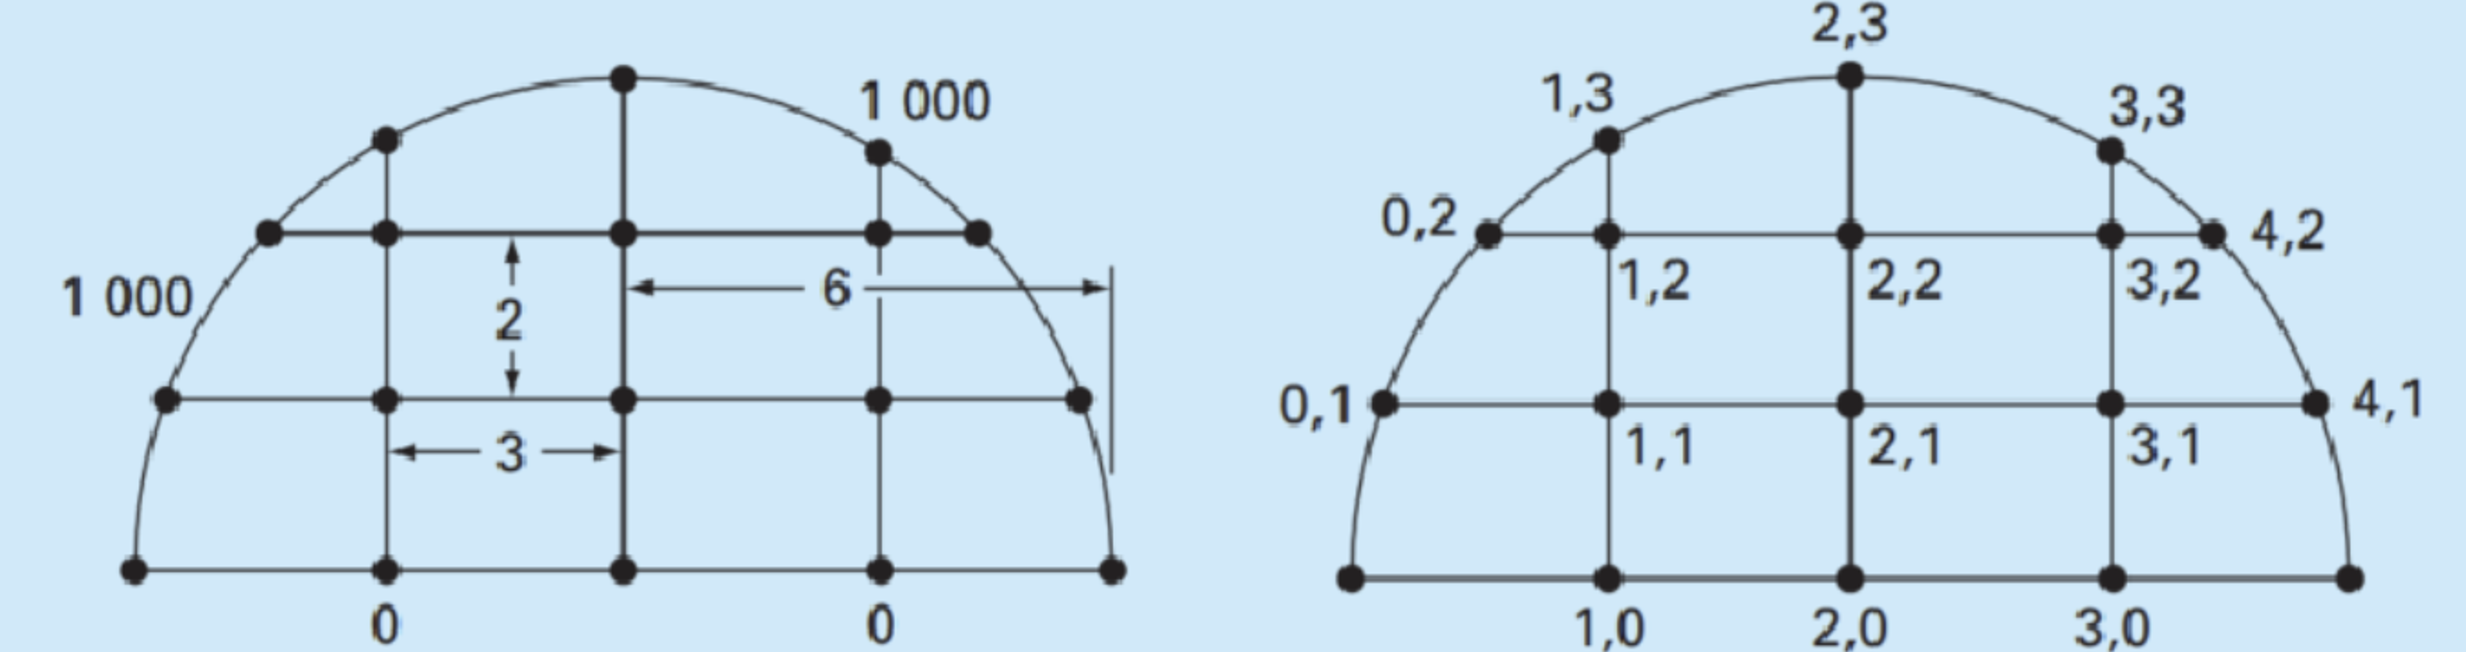

The function that creates the matrix, physical conditions and mathematical resolution.

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def generate_irregular_matrix(n, m, base, border):
    num_nodes = n * m
    A = np.zeros((num_nodes, num_nodes))
    b = np.zeros(num_nodes)

    for i in range(n):
        for j in range(m):
            node = i * m + j

            # Special nodes in the irregular border
            if (i, j) == (1, 1):
                A[node, node] = -4
                A[node, node - m] = 0.71
                A[node, node + m] = 0.63
                A[node, node - 1] = 1.33
                A[node, node + 1] = 1.33
                b[node] = 0
            elif (i, j) == (1, 2):
                A[node, node] = -4
                A[node, node - m] = 0.95
                A[node, node + m] =  0.47
                A[node, node - 1] = 0.97
                A[node, node + 1] = 1.62
                b[node] = 0
            elif (i, j) == (3, 2):
                A[node, node] = -4
                A[node, node - m] = 0.63
                A[node, node + m] = 0.71
                A[node, node - 1] = 1.33
                A[node, node + 1] = 1.33
                b[node] = 0
            elif (i, j) == (3, 1):
                A[node, node] = -4
                A[node, node - m] = 0.47
                A[node, node + m] = 0.95
                A[node, node - 1] = 0.97
                A[node, node + 1] = 1.62
                b[node] = 0

            # Border values

            elif i == 0:
                A[node, node] = 1
                b[node] = border
            elif i == n - 1:
                A[node, node] = 1
                b[node] = base
            elif j == m - 1:
                A[node, node] = 1
                b[node] = border
            elif j == 0:
                A[node, node] = 1
                b[node] = border
            else:
                A[node, node] = 4
                if i > 0: A[node, node - m] = -1
                if i < n - 1: A[node, node + m] = -1
                if j > 0: A[node, node - 1] = -1
                if j < m - 1: A[node, node + 1] = -1
    return A, b
#conditions
base = 0
border = 1000
n = m = 5


A, b = generate_irregular_matrix(n, m, base, border)
x = np.linalg.solve(A,b)
potential_distribution = x.reshape((n,m))
z = potential_distribution


Calculus of the flux module and vectorized graph





<>:34: SyntaxWarning: invalid escape sequence '\P'
<>:34: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_4584/1349635603.py:34: SyntaxWarning: invalid escape sequence '\P'
  cbar = fig.colorbar(im, ax=ax, label='Potential Value ($\Phi$)')


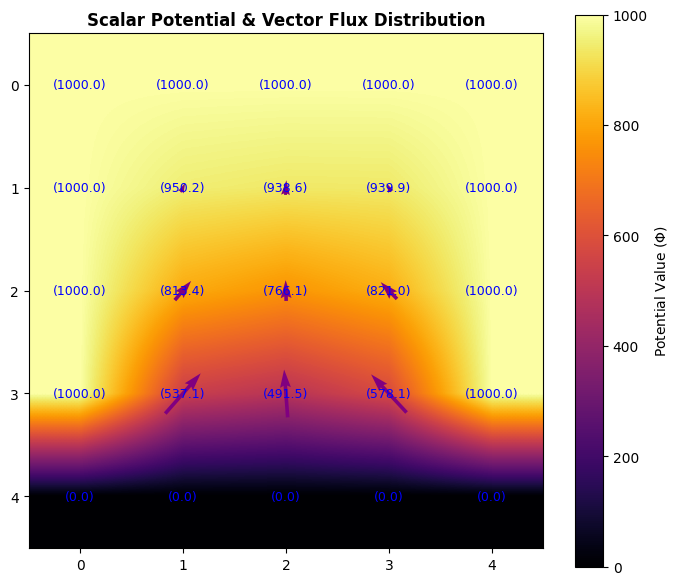

In [20]:
e = 2
Delta_x = 3
Delta_y = 2

Dx = np.zeros([5,5])
Dy = np.zeros([5,5])
flux = np.zeros([5,5])

n, m = z.shape

for i in range(1, n-1):
    for j in range(1, m-1):
        alpha_1 = 1
        alpha_2 = 1
        beta_1 = 1
        beta_2 = 1

        if (i,j) == (1,1): alpha_1 = 0.88
        elif (i,j) == (1,2): alpha_2 = 0.49; beta_2 = 0.6
        elif (i,j) == (3,1): alpha_2 = 0.88
        elif (i,j) == (3,2): alpha_2 = 0.49; beta_2 = 0.6

        #x and y components of the flux

        Dx[i,j] = -e * (z[i+1, j] - z[i-1, j]) / ((alpha_1 + alpha_2) * Delta_x)
        Dy[i,j] = -e * (z[i, j+1] - z[i, j-1]) / ((beta_1 + beta_2) * Delta_y)

        #flux module

        flux[i,j] = np.sqrt(abs(Dx[i,j]**2 + Dy[i,j]**2))


# VISUALIZATION: Scalar Potential Field & Vector Flux Fields

fig, ax = plt.subplots(figsize=(7, 6))

# Scalar heatmap matrix
im = ax.imshow(z, cmap='inferno', interpolation='bilinear')
cbar = fig.colorbar(im, ax=ax, label='Potential Value ($\Phi$)')

# Notation values
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        ax.text(j, i, f'({z[i,j]:.1f})', ha='center', va='center', color='blue', fontsize=9)


# Generates arrows that show the physical direction of the fluxes calculated in your loop
X, Y = np.meshgrid(np.arange(m), np.arange(n))
ax.quiver(X[1:-1, 1:-1], Y[1:-1, 1:-1], Dy[1:-1, 1:-1], Dx[1:-1, 1:-1],
          color='purple', scale=None, pivot='middle', width=0.007)

ax.set_title('Scalar Potential & Vector Flux Distribution', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The heat map illustrates how the internal cells absorb the boundary condition potentials. The regular margins maintain a saturated profile ($\Phi = 1000$), while the asymmetric decay is governed directly by the scaling corrections introduced inside generate_irregular_matrix.

The overlay arrows (derived from your components Dx and Dy) point along the direction of maximum rate of change (gradient descent). Near the asymmetrical coordinates, the flow fields distort significantly, capturing the physical geometry of the system without requiring mesh refinement.